In [37]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

normal = np.load('/content/anomalyDetection_Normal.npy')
issue = np.load('/content/anomalyDetection_Issue.npy')
labels = np.load('/content/anomalyDetection_Labels.npy')

print(f"Normal shape: {normal.shape}")
print(f"Issue shape:  {issue.shape}")
print(f"Labels shape: {labels.shape}")
print("Label values:", np.unique(labels))

Normal shape: (1000, 85)
Issue shape:  (400, 85)
Labels shape: (400,)
Label values: [0. 1.]


In [38]:
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

In [39]:
scaler_normal = StandardScaler()
normal_scaled = scaler_normal.fit_transform(normal)

scaler_issue = StandardScaler()
issue_scaled = scaler_issue.fit_transform(issue)

X_train = torch.tensor(normal_scaled, dtype=torch.float32)
X_test  = torch.tensor(issue_scaled, dtype=torch.float32)

batch_size = 64
train_ds = TensorDataset(X_train)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [40]:
input_dim = normal.shape[1]
print(input_dim)
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder(input_dim,latent_dim=8)
print(model)


85
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=85, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Linear(in_features=8, out_features=8, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=85, bias=True)
  )
)


Epoch 10/100  Loss: 0.692980
Epoch 20/100  Loss: 0.595857
Epoch 30/100  Loss: 0.482304
Epoch 40/100  Loss: 0.412827
Epoch 50/100  Loss: 0.382572
Epoch 60/100  Loss: 0.358538
Epoch 70/100  Loss: 0.340064
Epoch 80/100  Loss: 0.323562
Epoch 90/100  Loss: 0.311775
Epoch 100/100  Loss: 0.300641


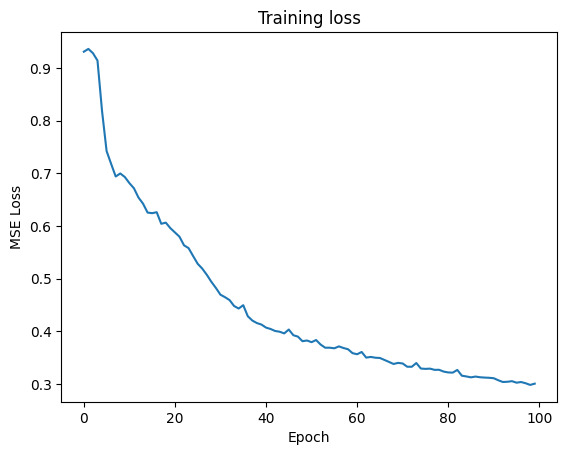

In [41]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for (batch,) in train_dl:
        optimizer.zero_grad()
        recon = model(batch)
        loss  = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_dl)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}  Loss: {avg_loss:.6f}")

plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training loss'); plt.show()


In [42]:
model.eval()
with torch.no_grad():
    recon_normal = model(X_train)
    recon_issue  = model(X_test)

err_normal = ((X_train - recon_normal)**2).mean(dim=1).numpy()
err_issue  = ((X_test  - recon_issue )**2).mean(dim=1).numpy()

In [43]:
threshold = np.percentile(err_normal, 99)
print("Threshold:", threshold)

predictions = (err_issue > threshold).astype(int)

Threshold: 1.5361998


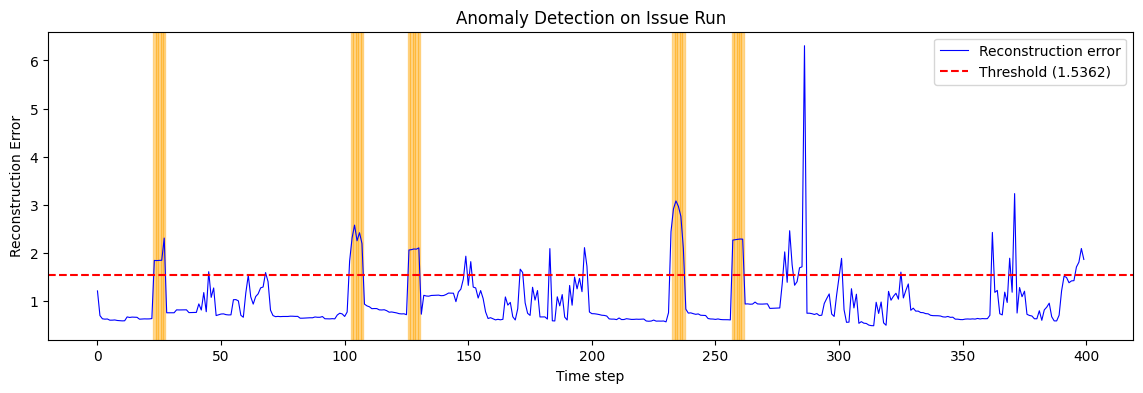

In [44]:
plt.figure(figsize=(14, 4))
plt.plot(err_issue, label='Reconstruction error', color='blue', lw=0.8)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')

anomaly_idx = np.where(labels == 1)[0]
for i in anomaly_idx:
    plt.axvspan(i-0.5, i+0.5, color='orange', alpha=0.4)

plt.legend()
plt.title('Anomaly Detection on Issue Run')
plt.xlabel('Time step'); plt.ylabel('Reconstruction Error')
plt.show()

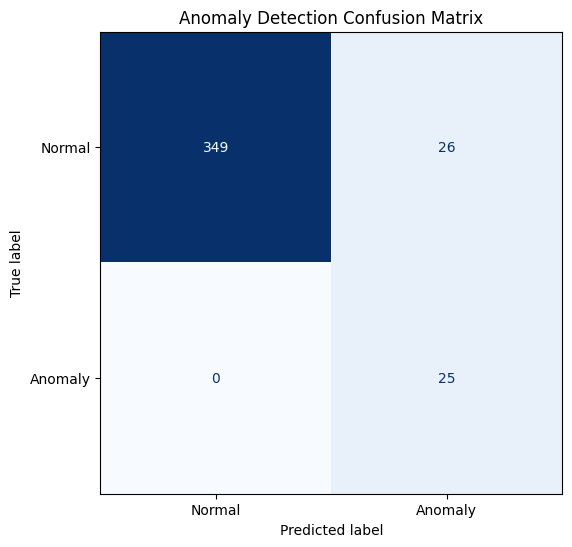

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96       375
     Anomaly       0.49      1.00      0.66        25

    accuracy                           0.94       400
   macro avg       0.75      0.97      0.81       400
weighted avg       0.97      0.94      0.94       400

ROC-AUC: 0.98336


In [45]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax,colorbar=False)
plt.title('Anomaly Detection Confusion Matrix')
plt.show()

print(classification_report(labels, predictions, target_names=['Normal', 'Anomaly']))
print("ROC-AUC:", roc_auc_score(labels, err_issue))